=== Storytelling Visual (OpenRouter) ===


[Generando leyenda...]

Error: {"error":{"message":"Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits","code":402}}
─── Leyenda ───
None

[Generando imagen...]



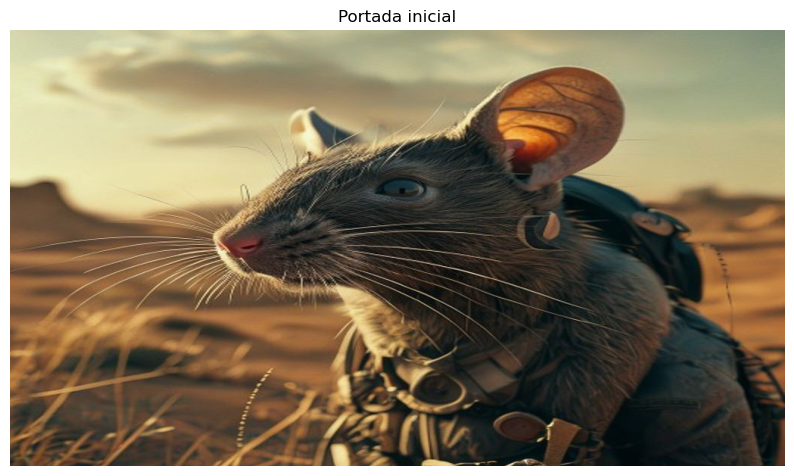


─── Feedback ───

[Generando versión mejorada...]

Error: {"error":{"message":"Insufficient credits. This account never purchased credits. Make sure your key is on the correct account or org, and if so, purchase more at https://openrouter.ai/settings/credits","code":402}}
─── Leyenda Final ───
None


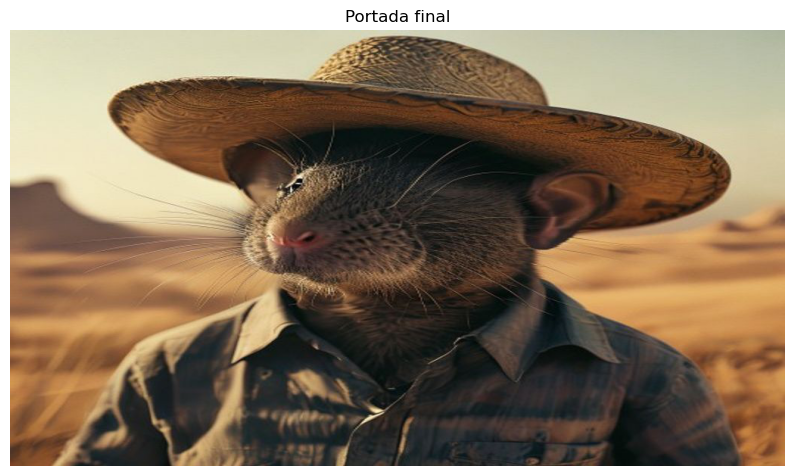


¡Proceso completado!


In [ ]:
import requests
import os
from dotenv import load_dotenv
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

#1. Configuración 

load_dotenv()

API_KEY = os.getenv("OPENROUTER_API_KEY")
MODEL = "sourceful/riverflow-v2-fast-preview"

#2. Generar texto (OpenRouter) 

def generar_leyenda(prompt):
    url = "https://openrouter.ai/api/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    data = {
        "model": MODEL,
        "messages": [
            {"role": "user", "content": prompt}
        ]
    }

    response = requests.post(url, headers=headers, json=data)

    if response.status_code != 200:
        print("Error:", response.text)
        return None

    return response.json()["choices"][0]["message"]["content"]


#3. Generar imagen

def generar_imagen(prompt):
    url = "https://image.pollinations.ai/prompt/"
    
    params = {
        "width": 1024,
        "height": 576,
        "seed": 42,
        "model": "flux"
    }

    response = requests.get(url + prompt, params=params)

    if response.status_code != 200:
        print("Error imagen:", response.status_code)
        return None

    if "image" not in response.headers.get("Content-Type", ""):
        print("Respuesta no es imagen")
        print(response.text[:200])
        return None

    try:
        return Image.open(BytesIO(response.content))
    except:
        return None


#4. Inputs

print("=== Storytelling Visual (OpenRouter) ===\n")

personaje = input("Introduce un personaje: ")
escenario = input("Introduce un escenario: ")

#5. Prompt inicial

prompt = f"""
Eres un narrador visual cinematográfico.

Escribe una leyenda breve (2-3 frases evocadoras).

Personaje: {personaje}
Escenario: {escenario}

Solo la leyenda.
"""

prompt_imagen = f"""
Cinematic scene, movie poster, photorealistic.
Character: {personaje}
Scene: {escenario}
"""

#6. Generación inicial

def mostrar_imagen(img, titulo="Imagen"):
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(titulo)
    plt.show()

print("\n[Generando leyenda...]\n")
leyenda1 = generar_leyenda(prompt)

print("─── Leyenda ───")
print(leyenda1)

print("\n[Generando imagen...]\n")
imagen1 = generar_imagen(prompt_imagen)

if imagen1:
    # imagen1.save("portada_inicial.png")
    mostrar_imagen(imagen1, "Portada inicial")
else:
    print("No se pudo generar imagen")

#7. Feedback 

print("\n─── Feedback ───")
feedback = input("¿Qué cambios te gustaría hacer?: ")

#8. Iteración

prompt_v2 = f"""
{prompt}

Leyenda anterior:
{leyenda1}

Mejora con este feedback:
{feedback}
"""

prompt_imagen_v2 = f"""
{prompt_imagen}
Additional instructions: {feedback}
"""

print("\n[Generando versión mejorada...]\n")

leyenda2 = generar_leyenda(prompt_v2)
imagen2 = generar_imagen(prompt_imagen_v2)

#9. Resultado final

print("─── Leyenda Final ───")
print(leyenda2)

if imagen2:
    # imagen2.save("portada_final.png")
    mostrar_imagen(imagen2, "Portada final")
else:
    print("No se pudo generar imagen final")

print("\n¡Proceso completado!")

In [6]:
# for model in client.models.list():
#     print(model.name)